
# Model 1: Temperature effect on normalized PV performance

This notebook implements the first Bayesian model for the PV project.

Research question:

$$
P(\beta_T < 0 \mid data)
$$

Does higher PV module temperature decrease normalized PV performance?

The model uses preprocessed data. Expected columns:

- `logPR` and `x_T`

or alternatively:

- `PR` and `T_module_C`

where:

$$
x_T = \frac{T_m - 25}{10}
$$

so one unit of `x_T` means a temperature increase of 10 degC.



## Model specification

The response variable is:

$$
y_i = \log(PR_i)
$$

The model is:

$$
y_i \sim StudentT(\nu, \mu_i, \sigma)
$$

$$
\mu_i = \alpha + \beta_T x_{T,i}
$$

where:

- $\alpha$ is the intercept, interpreted as the expected $\log(PR)$ when $x_T=0$, which corresponds to a module temperature of $T_m=25$ degC. On the original PR scale, $\exp(\alpha)$ is the expected normalized performance at this reference temperature. If the observed data contain few or no measurements close to 25 degC, this intercept should be treated mainly as a reference point for the regression line rather than as a directly observed operating condition.
- $\beta_T$ is the temperature coefficient. It is the expected change in $\log(PR)$ for a one-unit increase in $x_T$, i.e. for a 10 degC increase in module temperature. On the PR scale, $100(\exp(\beta_T)-1)$ is the approximate percentage change in normalized performance for a 10 degC increase. A negative value of $\beta_T$ therefore corresponds to temperature-related performance loss.
- $\sigma$ is residual variability around the mean relation.
- $\nu$ controls the tail heaviness of the Student-t distribution.

The Student-t likelihood is used instead of a normal likelihood because PV monitoring data can still contain atypical observations after preprocessing, for example due to short cloud passages, temporary shading, sensor noise, or inverter behaviour. The heavier tails make the model less sensitive to such remaining outliers.

The key quantity is:

$$
P(\beta_T < 0 \mid data)
$$

This posterior probability directly evaluates whether the data support a negative temperature effect on normalized PV performance.


In [14]:

from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

RANDOM_SEED = 123
rng = np.random.default_rng(RANDOM_SEED)

# Set to None if you want to use all data.
# During development 3000-5000 rows are enough and much faster.
MAX_N = 5000

CANDIDATE_DATA_FILES = [
    Path("clean_ground_2016_summer.csv"),
    Path("onemin-Ground-2016/clean_ground_2016_summer.csv"),
    Path("onemin-Ground-2016/2016/clean_ground_2016_summer.csv"),
    Path("data/clean_ground_2016_summer.csv"),
]

for p in CANDIDATE_DATA_FILES:
    if p.exists():
        CLEAN_DATA_PATH = p
        break
else:
    raise FileNotFoundError(
        "Clean data file not found. Put clean_ground_2016_summer.csv in the project folder "
        "or update CANDIDATE_DATA_FILES."
    )

print("Using clean data:", CLEAN_DATA_PATH)

STAN_MODEL_PATH = Path("model_1_temperature.stan")
STAN_PRIOR_PATH = Path("model_1_temperature_prior_predictive.stan")


Using clean data: onemin-Ground-2016/2016/clean_ground_2016_summer.csv



## Load preprocessed data


In [15]:

df = pd.read_csv(CLEAN_DATA_PATH)

print("Raw data shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

if "logPR" not in df.columns:
    if "PR" not in df.columns:
        raise ValueError("Dataset must contain either 'logPR' or 'PR'.")
    df["logPR"] = np.log(df["PR"])

if "x_T" not in df.columns:
    if "T_module_C" not in df.columns:
        raise ValueError("Dataset must contain either 'x_T' or 'T_module_C'.")
    df["x_T"] = (df["T_module_C"] - 25.0) / 10.0

data = df[["logPR", "x_T"]].replace([np.inf, -np.inf], np.nan).dropna().copy()

if MAX_N is not None and len(data) > MAX_N:
    data = data.sample(n=MAX_N, random_state=RANDOM_SEED).sort_index()

print("Model data shape:", data.shape)
display(data.describe())

y = data["logPR"].to_numpy(dtype=float)
x_T = data["x_T"].to_numpy(dtype=float)
PR_obs = np.exp(y)
N = len(y)

stan_data = {
    "N": N,
    "x_T": x_T,
    "y": y,
}

prior_data = {
    "N": N,
    "x_T": x_T,
}


Raw data shape: (3558, 17)
Columns:
['timestamp', 'P_DC_kW', 'G_POA_Wm2', 'T_module_C', 'T_amb_C', 'wind_ms', 'hour', 'month', 'day', 'dG_POA', 'expected_P_DC_kW', 'PR', 'logPR', 'x_T', 'z_wind', 'z_Tamb', 'power_ratio']
Model data shape: (3558, 2)


,logPR,x_T
count,3558.000000,3558.000000
mean,-0.115657,2.989113
std,0.030799,0.572175
min,-0.287484,0.356000
25%,-0.134152,2.670000
50%,-0.118366,3.066000
75%,-0.095295,3.408750
max,0.041162,4.168000



## Exploratory plots


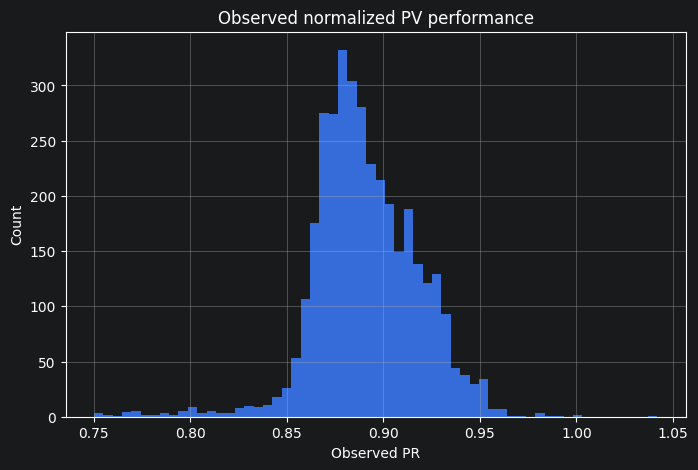

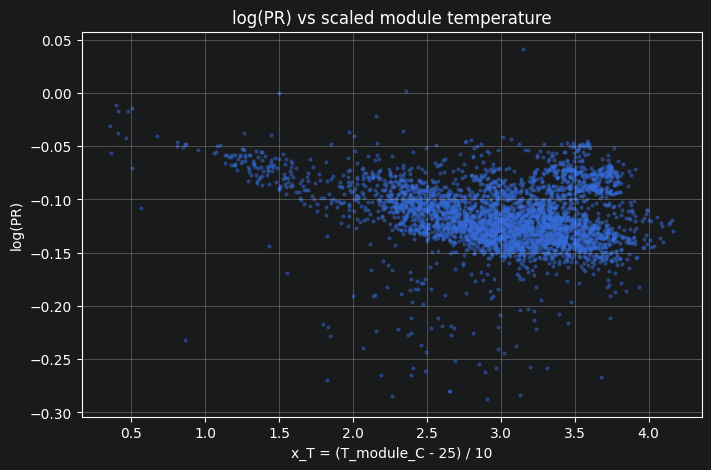

In [16]:

plt.figure(figsize=(8, 5))
plt.hist(PR_obs, bins=60)
plt.xlabel("Observed PR")
plt.ylabel("Count")
plt.title("Observed normalized PV performance")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(x_T, y, s=4, alpha=0.4)
plt.xlabel("x_T = (T_module_C - 25) / 10")
plt.ylabel("log(PR)")
plt.title("log(PR) vs scaled module temperature")
plt.grid(True)
plt.show()



## Priors

The priors are weakly informative:

$$
\alpha \sim Normal(\log(0.85), 0.20)
$$

because normalized PV performance is expected to be below or near 1. This prior is placed on the log scale, so it represents prior beliefs about the expected PR at the reference temperature $T_m=25$ degC.

$$
\beta_T \sim Normal(0, 0.08)
$$

This prior does not force the effect to be negative. It allows either positive or negative temperature associations, while making very large changes in $\log(PR)$ per 10 degC unlikely.

$$
\sigma \sim Exponential(10)
$$

This prefers smaller residual variation, but allows larger noise if needed.

$$
\nu = 2 + Exponential(0.1)
$$

This gives a robust Student-t likelihood. Smaller values of $\nu$ allow heavier tails, while larger values make the likelihood closer to a normal distribution.



## Prior predictive checks


In [17]:

prior_model = CmdStanModel(stan_file=str(STAN_PRIOR_PATH))

prior_fit = prior_model.sample(
    data=prior_data,
    fixed_param=True,
    chains=1,
    iter_sampling=2000,
    seed=RANDOM_SEED,
)

alpha_prior = prior_fit.stan_variable("alpha")
beta_T_prior = prior_fit.stan_variable("beta_T")
sigma_prior = prior_fit.stan_variable("sigma")
nu_prior = prior_fit.stan_variable("nu")
PR_prior = prior_fit.stan_variable("PR_prior")

print("Prior alpha:", np.percentile(alpha_prior, [2.5, 50, 97.5]))
print("Prior beta_T:", np.percentile(beta_T_prior, [2.5, 50, 97.5]))
print("Prior sigma:", np.percentile(sigma_prior, [2.5, 50, 97.5]))
print("Prior nu:", np.percentile(nu_prior, [2.5, 50, 97.5]))


01:14:10 - cmdstanpy - INFO - compiling stan file /Users/jwiater/Documents/private/da_project/model_1_temperature_prior_predictive.stan to exe file /Users/jwiater/Documents/private/da_project/model_1_temperature_prior_predictive
01:14:14 - cmdstanpy - INFO - compiled model executable: /Users/jwiater/Documents/private/da_project/model_1_temperature_prior_predictive
01:14:15 - cmdstanpy - INFO - CmdStan start processing
chain 1: 100%|██████████| 3000/3000 [00:05<00:00, 584.03it/s, (Sampling completed)]


01:14:20 - cmdstanpy - INFO - CmdStan done processing.



Prior alpha: [-0.55076309 -0.17433086  0.22971321]
Prior beta_T: [-1.60838779e-01 -1.12191006e-04  1.57496016e-01]
Prior sigma: [0.00257277 0.06775493 0.36795804]
Prior nu: [ 2.19452756  8.7140685  39.18474222]


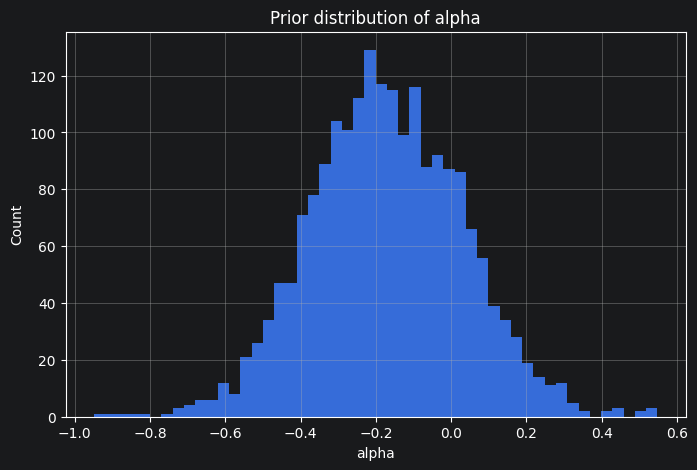

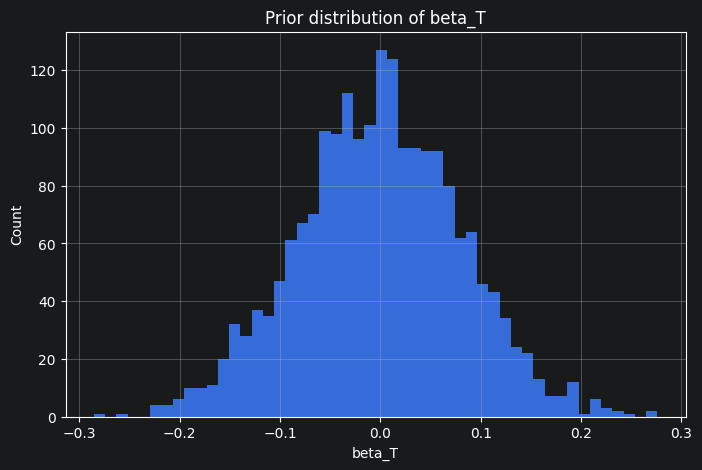

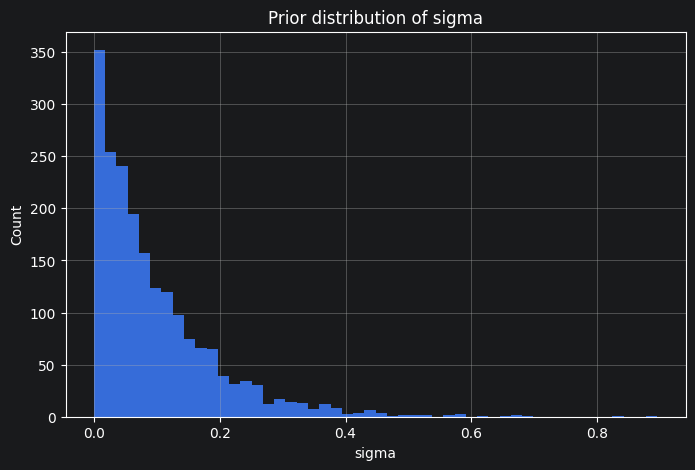

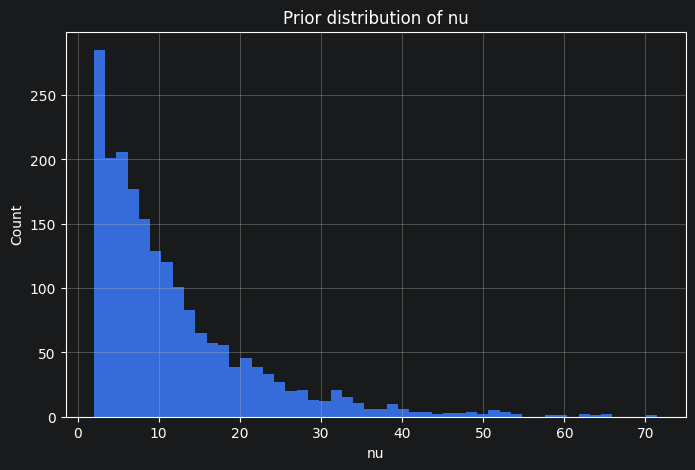

In [18]:

plt.figure(figsize=(8, 5))
plt.hist(alpha_prior, bins=50)
plt.xlabel("alpha")
plt.ylabel("Count")
plt.title("Prior distribution of alpha")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(beta_T_prior, bins=50)
plt.xlabel("beta_T")
plt.ylabel("Count")
plt.title("Prior distribution of beta_T")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(sigma_prior, bins=50)
plt.xlabel("sigma")
plt.ylabel("Count")
plt.title("Prior distribution of sigma")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(nu_prior, bins=50)
plt.xlabel("nu")
plt.ylabel("Count")
plt.title("Prior distribution of nu")
plt.grid(True)
plt.show()


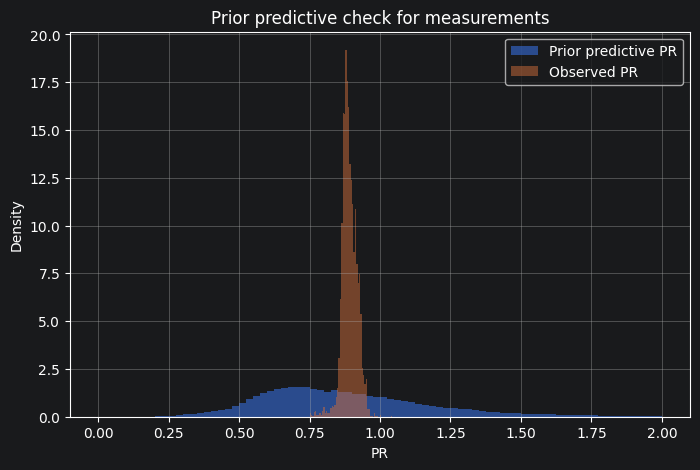

Prior predictive PR percentiles:
[0.33941025 0.47478732 0.83634132 1.52597607 2.08484653]


In [19]:

prior_flat = PR_prior.reshape(-1)
prior_flat = prior_flat[np.isfinite(prior_flat)]
prior_flat = prior_flat[(prior_flat > 0) & (prior_flat < 2.0)]

plt.figure(figsize=(8, 5))
plt.hist(prior_flat, bins=80, density=True, alpha=0.6, label="Prior predictive PR")
plt.hist(PR_obs, bins=60, density=True, alpha=0.5, label="Observed PR")
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Prior predictive check for measurements")
plt.legend()
plt.grid(True)
plt.show()

print("Prior predictive PR percentiles:")
print(np.percentile(PR_prior.reshape(-1), [1, 5, 50, 95, 99]))



## Fit Model 1


In [20]:

model = CmdStanModel(stan_file=str(STAN_MODEL_PATH))

fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=RANDOM_SEED,
    adapt_delta=0.90,
    max_treedepth=12,
)


01:14:22 - cmdstanpy - INFO - compiling stan file /Users/jwiater/Documents/private/da_project/model_1_temperature.stan to exe file /Users/jwiater/Documents/private/da_project/model_1_temperature
01:14:27 - cmdstanpy - INFO - compiled model executable: /Users/jwiater/Documents/private/da_project/model_1_temperature
01:14:27 - cmdstanpy - INFO - CmdStan start processing
chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   5%|▌         | 100/2000 [00:00<00:02, 804.80it/s, (Warmup)]


chain 2:  15%|█▌        | 300/2000 [00:01<00:09, 180.51it/s, (Warmup)]

chain 3:  10%|█         | 200/2000 [00:01<00:19, 92.00it/s, (Warmup)] 


chain 1:  20%|██        | 400/2000 [00:02<00:10, 148.73it/s, (Warmup)]


chain 4:  15%|█▌        | 300/2000 [00:02<00:16, 105.02it/s, (Warmup)]

chain 2:  30%|███       | 600/2000 [00:03<00:07, 186.75it/s, (Warmup)]

chain 1:  


01:14:42 - cmdstanpy - INFO - CmdStan done processing.
01:14:42 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_1_temperature.stan', line 29, column 2 to column 31)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'model_1_temperature.stan', line 29, column 2 to column 31)
	Exception: student_t_lpdf: Degrees of freedom parameter is inf, but must be positive finite! (in 'model_1_temperature.stan', line 29, column 2 to column 31)
	Exception: student_t_lpdf: Scale parameter is 0, but must be positive finite! (in 'model_1_temperature.stan', line 29, column 2 to column 31)
Exception: student_t_lpdf: Scale parameter is 0, but must be positive finite! (in 'model_1_temperature.stan', line 29, column 2 to column 31)
	Exception: student_t_lpdf: Scale parameter is 0, but must be positive finite! (in 'model_1_temperature.stan', line 29, column 2 to column 31)
	Ex


## Sampling diagnostics

We check:

- divergences,
- R-hat,
- effective sample size.


In [21]:

print(fit.diagnose())

summary = fit.summary()
display(summary.loc[["alpha", "beta_T", "sigma", "nu"]])

try:
    divergences = fit.divergences
    print("Number of divergences:", int(np.sum(divergences)))
except Exception:
    print("Could not read divergences directly. Use fit.diagnose() above.")


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
alpha,-0.060637,0.000054,0.002394,0.002381,-0.064567,-0.060624,-0.056722,2023.84,2232.31,63.2807,1.00269
beta_T,-0.018749,0.000019,0.000818,0.000811,-0.020078,-0.018750,-0.017405,1870.91,2261.54,58.4988,1.00202
sigma,0.021080,0.000017,0.000482,0.000473,0.020280,0.021088,0.021890,815.87,1122.35,25.5103,1.00386
nu,3.792070,0.009340,0.273821,0.268654,3.360770,3.782160,4.267110,871.52,1236.08,27.2503,1.00414


Number of divergences: 0



## Posterior for beta_T

Because:

$$
x_T = \frac{T_m - 25}{10}
$$

the coefficient $\beta_T$ describes the effect of +10 degC on $\log(PR)$.

Effect in percent for +10 degC:

$$
100(\exp(\beta_T)-1)
$$

Effect in percent for +1 degC:

$$
100(\exp(\beta_T/10)-1)
$$


P(beta_T < 0 | data) = 1.0000
beta_T posterior percentiles:
[-0.02035504 -0.01874976 -0.01713241]
Effect per +10 degC [%] percentiles:
[-2.01492773 -1.85750767 -1.69864867]
Effect per +1 degC [%] percentiles:
[-0.2033434  -0.18732193 -0.17117744]


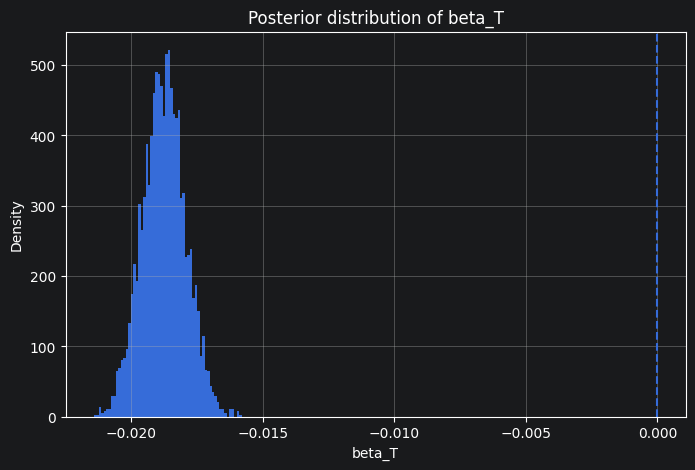

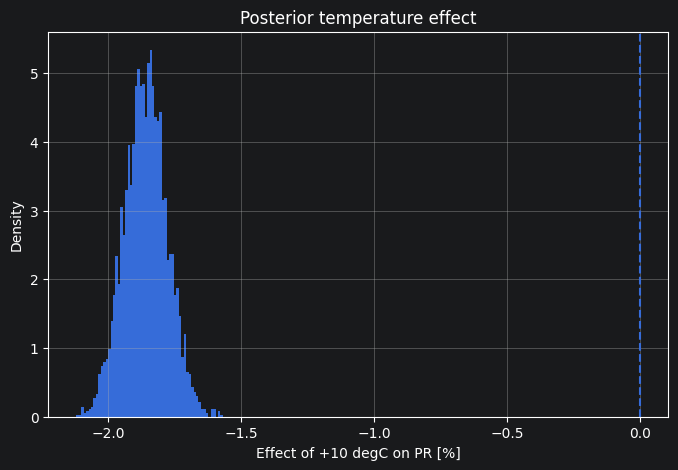

In [22]:

beta_T = fit.stan_variable("beta_T")

prob_negative = np.mean(beta_T < 0)
effect_10C_pct = 100 * (np.exp(beta_T) - 1)
effect_1C_pct = 100 * (np.exp(beta_T / 10) - 1)

print(f"P(beta_T < 0 | data) = {prob_negative:.4f}")
print("beta_T posterior percentiles:")
print(np.percentile(beta_T, [2.5, 50, 97.5]))

print("Effect per +10 degC [%] percentiles:")
print(np.percentile(effect_10C_pct, [2.5, 50, 97.5]))

print("Effect per +1 degC [%] percentiles:")
print(np.percentile(effect_1C_pct, [2.5, 50, 97.5]))

plt.figure(figsize=(8, 5))
plt.hist(beta_T, bins=60, density=True)
plt.axvline(0, linestyle="--")
plt.xlabel("beta_T")
plt.ylabel("Density")
plt.title("Posterior distribution of beta_T")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(effect_10C_pct, bins=60, density=True)
plt.axvline(0, linestyle="--")
plt.xlabel("Effect of +10 degC on PR [%]")
plt.ylabel("Density")
plt.title("Posterior temperature effect")
plt.grid(True)
plt.show()



## Posterior predictive checks


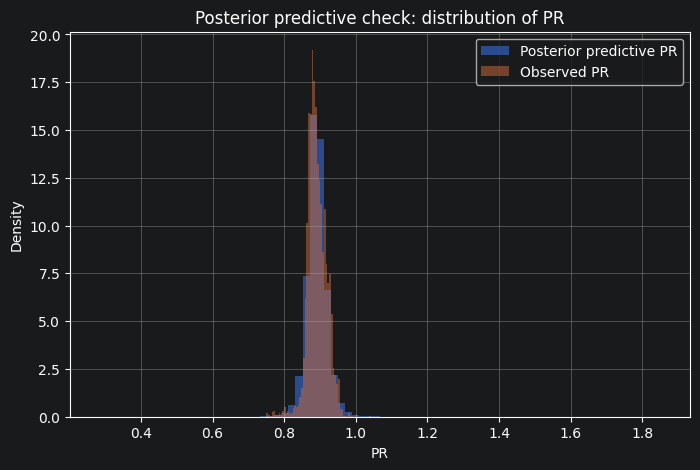

In [23]:

y_pred = fit.stan_variable("y_pred")
PR_pred = fit.stan_variable("PR_pred")

idx = rng.choice(PR_pred.shape[0], size=min(200, PR_pred.shape[0]), replace=False)
PR_ppc_flat = PR_pred[idx, :].reshape(-1)
PR_ppc_flat = PR_ppc_flat[np.isfinite(PR_ppc_flat)]
PR_ppc_flat = PR_ppc_flat[(PR_ppc_flat > 0) & (PR_ppc_flat < 2.0)]

plt.figure(figsize=(8, 5))
plt.hist(PR_ppc_flat, bins=80, density=True, alpha=0.6, label="Posterior predictive PR")
plt.hist(PR_obs, bins=60, density=True, alpha=0.5, label="Observed PR")
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Posterior predictive check: distribution of PR")
plt.legend()
plt.grid(True)
plt.show()


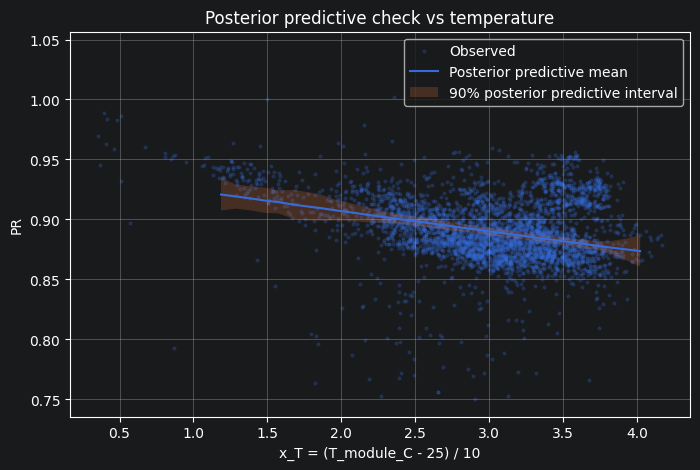

In [24]:

bins = np.linspace(x_T.min(), x_T.max(), 40)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

mean_pred = []
low_pred = []
high_pred = []
mean_obs = []

for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (x_T >= lo) & (x_T < hi)

    if np.sum(mask) < 10:
        mean_pred.append(np.nan)
        low_pred.append(np.nan)
        high_pred.append(np.nan)
        mean_obs.append(np.nan)
        continue

    pred_bin = PR_pred[:, mask].mean(axis=1)

    mean_pred.append(np.mean(pred_bin))
    low_pred.append(np.percentile(pred_bin, 5))
    high_pred.append(np.percentile(pred_bin, 95))
    mean_obs.append(np.mean(PR_obs[mask]))

mean_pred = np.array(mean_pred)
low_pred = np.array(low_pred)
high_pred = np.array(high_pred)
mean_obs = np.array(mean_obs)

plt.figure(figsize=(8, 5))
plt.scatter(x_T, PR_obs, s=4, alpha=0.20, label="Observed")
plt.plot(bin_centers, mean_pred, label="Posterior predictive mean")
plt.fill_between(
    bin_centers,
    low_pred,
    high_pred,
    alpha=0.25,
    label="90% posterior predictive interval",
)
plt.xlabel("x_T = (T_module_C - 25) / 10")
plt.ylabel("PR")
plt.title("Posterior predictive check vs temperature")
plt.legend()
plt.grid(True)
plt.show()



## Interpretation

Model 1 estimates the empirical association between module temperature and normalized PV performance using temperature as the only predictor. The posterior probability that the temperature coefficient is negative was 1.0, which indicates strong support for a negative temperature effect under this model. The median effect of a +10 degC increase in module temperature was -1.87%, with a 95% credible interval of [-2.00%, -1.74%]. Because wind speed is not included explicitly, possible wind-related cooling effects remain part of the unexplained variation, so the result should be interpreted as a temperature-only association rather than a complete causal explanation.



## Save ArviZ object for model comparison

This file will be used later for WAIC and PSIS-LOO comparison with Model 2, which extends Model 1 by adding wind speed as an additional predictor.


In [25]:

idata1 = az.from_cmdstanpy(
    posterior=fit,
    posterior_predictive=["y_pred"],
    observed_data={"y": y},
    log_likelihood=["log_lik"],
)

with open("idata_model1_temperature.pkl", "wb") as f:
    pickle.dump(idata1, f)

print("Saved idata_model1_temperature.pkl")


Saved idata_model1_temperature.pkl
